In [499]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [500]:
df = pd.read_csv('CarPrice_Assignment.csv')

In [501]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 205 entries, 0 to 204
Data columns (total 26 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   car_ID            205 non-null    int64  
 1   symboling         205 non-null    int64  
 2   CarName           205 non-null    object 
 3   fueltype          205 non-null    object 
 4   aspiration        205 non-null    object 
 5   doornumber        205 non-null    object 
 6   carbody           205 non-null    object 
 7   drivewheel        205 non-null    object 
 8   enginelocation    205 non-null    object 
 9   wheelbase         205 non-null    float64
 10  carlength         205 non-null    float64
 11  carwidth          205 non-null    float64
 12  carheight         205 non-null    float64
 13  curbweight        205 non-null    int64  
 14  enginetype        205 non-null    object 
 15  cylindernumber    205 non-null    object 
 16  enginesize        205 non-null    int64  
 1

In [502]:
df.columns

Index(['car_ID', 'symboling', 'CarName', 'fueltype', 'aspiration',
       'doornumber', 'carbody', 'drivewheel', 'enginelocation', 'wheelbase',
       'carlength', 'carwidth', 'carheight', 'curbweight', 'enginetype',
       'cylindernumber', 'enginesize', 'fuelsystem', 'boreratio', 'stroke',
       'compressionratio', 'horsepower', 'peakrpm', 'citympg', 'highwaympg',
       'price'],
      dtype='object')

In [503]:
df = df.drop(['car_ID', 'CarName'], axis=1)

## model

In [504]:
num_features = df.select_dtypes(include=[np.number])
df['price_log'] = np.log1p(df['price'])
X = num_features.drop('price', axis=1).values
y = df['price_log'].values

In [505]:
def manual_train_test_split(X, y, test_size=0.8, random_state=None):
    if random_state is not None:
        np.random.seed(random_state)
    
    n_samples = len(y)
    n_test = int(n_samples * test_size)
    
    indices = np.arange(n_samples)
    np.random.shuffle(indices)
    
    # Split indices
    test_indices = indices[:n_test]
    train_indices = indices[n_test:]
    
    # Split data
    X_train, X_test = X[train_indices], X[test_indices]
    y_train, y_test = y[train_indices], y[test_indices]
    
    return X_train, X_test, y_train, y_test

# Split data
X_train, X_test, y_train, y_test = manual_train_test_split(
    X, y, test_size=0.8, random_state=42
)


In [506]:
def variance(y):
    if len(y) == 0:
        return 0
    y_mean = np.mean(y)
    return np.mean((y - y_mean) ** 2)

def best_split(X, y):
    best_gain = -np.inf
    best_feature = None
    best_threshold = None

    n_samples = len(y)
    parent_variance = variance(y)

    for feature in range(X.shape[1]):
        thresholds = np.unique(X[:, feature])
        
        for threshold in thresholds:
            left_idx = X[:, feature] <= threshold
            right_idx = X[:, feature] > threshold

            n_left, n_right = np.sum(left_idx), np.sum(right_idx)
            
            if n_left == 0 or n_right == 0:
                continue

            left_var = variance(y[left_idx])
            right_var = variance(y[right_idx])

            weighted_var = (n_left / n_samples) * left_var + (n_right / n_samples) * right_var

            gain = parent_variance - weighted_var
            
            if gain > best_gain:
                best_gain = gain
                best_feature = feature
                best_threshold = threshold
    
    return best_feature, best_threshold, best_gain

feature, threshold, gain = best_split(X_train, y_train)

print(f"Best Threshold: {threshold}")
print(f"Best Gain (Variance Reduction): {gain}")

feature_names = num_features.drop('price', axis=1).columns.tolist()
print(f"Best Feature Name: '{feature_names[feature]}'")

Best Threshold: 28.0
Best Gain (Variance Reduction): 0.16736012321247318
Best Feature Name: 'highwaympg'


In [507]:
X_np = np.asarray(X)
X_train_gs, X_val_gs, y_train_gs, y_val_gs = manual_train_test_split(X_np, y, test_size=0.2, random_state=0)

def build_tree(X, y, depth=0, max_depth=3, min_samples_split=2):
    # daun
    if len(y) < min_samples_split or depth >= max_depth:
        return {'type': 'leaf', 'value': np.mean(y)}
    feat, thr, gain = best_split(X, y)
    if feat is None or gain <= 0:
        return {'type': 'leaf', 'value': np.mean(y)}
    left_idx = X[:, feat] <= thr
    right_idx = ~left_idx
    if left_idx.sum() == 0 or right_idx.sum() == 0:
        return {'type': 'leaf', 'value': np.mean(y)}
    return {
        'type': 'node',
        'feature': feat,
        'threshold': thr,
        'left': build_tree(X[left_idx], y[left_idx], depth + 1, max_depth, min_samples_split),
        'right': build_tree(X[right_idx], y[right_idx], depth + 1, max_depth, min_samples_split)
    }

def predict_tree_single(node, x):
    if node['type'] == 'leaf':
        return node['value']
    if x[node['feature']] <= node['threshold']:
        return predict_tree_single(node['left'], x)
    else:
        return predict_tree_single(node['right'], x)

def predict_tree(node, X):
    return np.array([predict_tree_single(node, xi) for xi in X])

def rmse_np(y_true, y_pred):
    return np.sqrt(np.mean((y_true - y_pred) ** 2))

def r2_np(y_true, y_pred):
    ss_res = np.sum((y_true - y_pred) ** 2)
    ss_tot = np.sum((y_true - np.mean(y_true)) ** 2)
    return 1 - ss_res / ss_tot if ss_tot != 0 else 0.0

# grid search 
results = []
for max_depth in range(1, 11):
    tree = build_tree(X_train_gs, y_train_gs, max_depth=max_depth, min_samples_split=2)
    y_val_pred = predict_tree(tree, X_val_gs)
    r2 = r2_np(y_val_gs, y_val_pred)
    rm = rmse_np(y_val_gs, y_val_pred)
    results.append((max_depth, r2, rm))

# gambil r2 best
results.sort(key=lambda t: (t[1], -t[0]), reverse=True)
best_depth, best_r2, best_rmse = results[0]

print("Grid search results (max_depth, R2, RMSE):")
for depth, r2, rm in results:
    print(f"  depth={depth:2d} -> R2={r2:.4f}, RMSE={rm:.2f}")

print(f"\nBest max_depth = {best_depth}")

def fit_linear_regression(X, y):
    X_design = np.hstack([np.ones((X.shape[0], 1)), X])
    w = np.linalg.pinv(X_design.T @ X_design) @ (X_design.T @ y)
    return w

def predict_linear_regression(X, w):
    X_design = np.hstack([np.ones((X.shape[0], 1)), X])
    return X_design @ w

w = fit_linear_regression(X_train, y_train)
y_pred = predict_linear_regression(X_test, w)
if hasattr(X, 'columns'):
    feature_cols = X.columns
else:
    feature_cols = [f'feat_{i}' for i in range(X_np.shape[1])]

result_df = pd.DataFrame(X_test, columns=feature_cols)
result_df['actual_price'] = y_test
result_df['predicted_price'] = y_pred
print(result_df[['actual_price', 'predicted_price']].head(20))


Grid search results (max_depth, R2, RMSE):
  depth= 8 -> R2=0.8521, RMSE=0.21
  depth= 5 -> R2=0.8405, RMSE=0.21
  depth= 9 -> R2=0.8404, RMSE=0.21
  depth= 6 -> R2=0.8400, RMSE=0.21
  depth= 7 -> R2=0.8388, RMSE=0.21
  depth=10 -> R2=0.8283, RMSE=0.22
  depth= 4 -> R2=0.8146, RMSE=0.23
  depth= 2 -> R2=0.8135, RMSE=0.23
  depth= 3 -> R2=0.7893, RMSE=0.25
  depth= 1 -> R2=0.5589, RMSE=0.35

Best max_depth = 8
    actual_price  predicted_price
0      10.334003         9.870858
1       9.790328         9.604105
2       9.164296         9.064487
3       9.380168         9.639854
4      10.248813         9.999366
5       8.961879         8.838454
6       8.960468         9.061512
7       9.133351         9.015431
8       9.230045         9.479531
9       8.958797         9.048513
10      9.495219         9.401092
11      9.016634         9.039345
12      9.813618         9.593752
13      9.209240         9.175782
14     10.620376        10.753744
15      8.777864         8.747487
16      8

In [ ]:
threshold = np.median(y_test)
y_true_bin = (y_test >= threshold).astype(int)
y_pred_bin = (y_pred >= threshold).astype(int)

tp = int(np.sum((y_true_bin == 1) & (y_pred_bin == 1)))
tn = int(np.sum((y_true_bin == 0) & (y_pred_bin == 0)))
fp = int(np.sum((y_true_bin == 0) & (y_pred_bin == 1)))
fn = int(np.sum((y_true_bin == 1) & (y_pred_bin == 0)))

accuracy = (tp + tn) / len(y_true_bin) if len(y_true_bin) > 0 else 0.0
precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
recall = tp / (tp + fn) if (tp + fn) > 0 else 0.0
f1 = (2 * precision * recall) / (precision + recall) if (precision + recall) > 0 else 0.0
ss_res = np.sum((y_test - y_pred) ** 2)
ss_tot = np.sum((y_test - np.mean(y_test)) ** 2)
r_squarred = 1 - ss_res / ss_tot if ss_tot != 0 else 0.0

print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1 score:  {f1:.4f}")
print(f"R2:        {r_squarred:.4f}")

Accuracy:  0.8659
Precision: 0.8333
Recall:    0.9146
F1 score:  0.8721
R2:        0.7429


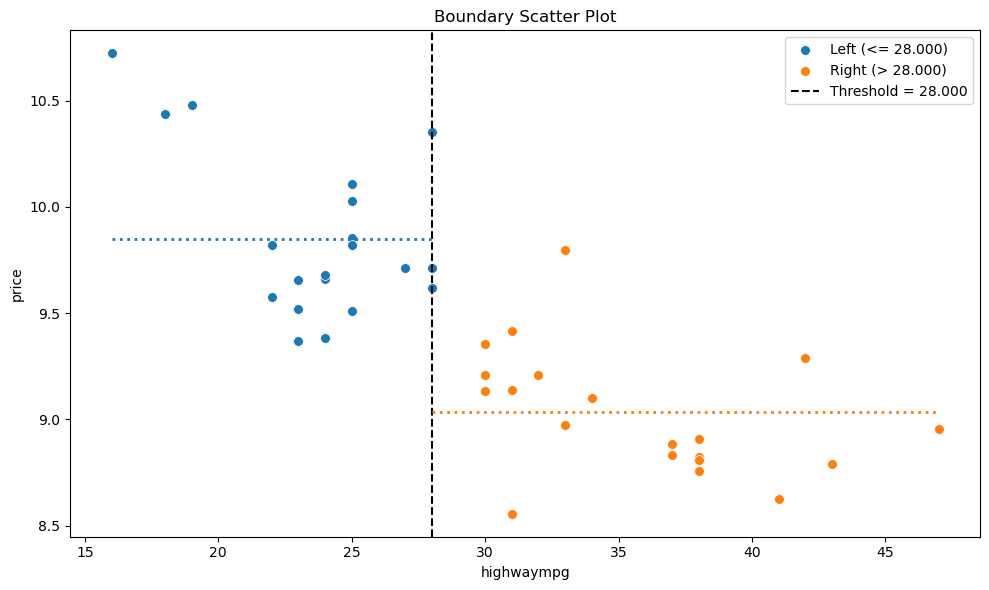

In [509]:
best_feature, best_threshold, best_gain = best_split(X_train, y_train)

if best_feature is None:
    print("No valid split found.")
else:
    fname = feature_names[best_feature]
    x = X_train[:, best_feature]
    left_mask = x <= best_threshold
    right_mask = x > best_threshold

    mean_left = np.mean(y_train[left_mask]) if left_mask.any() else np.nan
    mean_right = np.mean(y_train[right_mask]) if right_mask.any() else np.nan

    plt.figure(figsize=(10, 6))
    sns.scatterplot(x=x[left_mask], y=y_train[left_mask], color='C0', label=f'Left (<= {best_threshold:.3f})', s=50)
    sns.scatterplot(x=x[right_mask], y=y_train[right_mask], color='C1', label=f'Right (> {best_threshold:.3f})', s=50)

    xmin, xmax = x.min(), x.max()
    plt.axvline(best_threshold, color='k', linestyle='--', linewidth=1.5, label=f'Threshold = {best_threshold:.3f}')
    plt.hlines(mean_left, xmin, best_threshold, colors='C0', linestyles=':', linewidth=2)
    plt.hlines(mean_right, best_threshold, xmax, colors='C1', linestyles=':', linewidth=2)

    plt.xlabel(fname)
    plt.ylabel('price')
    plt.title('Boundary Scatter Plot')
    plt.legend()
    plt.tight_layout()
    plt.show()

## as

In [510]:
num_features = df.select_dtypes(include=[np.number])

In [511]:
# num_features.columns

In [512]:
X = num_features.drop('price', axis=1)
y = df['price'].values

In [513]:
X.shape

(205, 15)

In [514]:
y.shape

(205,)

In [515]:
df['price'].unique()

array([13495.   , 16500.   , 13950.   , 17450.   , 15250.   , 17710.   ,
       18920.   , 23875.   , 17859.167, 16430.   , 16925.   , 20970.   ,
       21105.   , 24565.   , 30760.   , 41315.   , 36880.   ,  5151.   ,
        6295.   ,  6575.   ,  5572.   ,  6377.   ,  7957.   ,  6229.   ,
        6692.   ,  7609.   ,  8558.   ,  8921.   , 12964.   ,  6479.   ,
        6855.   ,  5399.   ,  6529.   ,  7129.   ,  7295.   ,  7895.   ,
        9095.   ,  8845.   , 10295.   , 12945.   , 10345.   ,  6785.   ,
        8916.5  , 11048.   , 32250.   , 35550.   , 36000.   ,  5195.   ,
        6095.   ,  6795.   ,  6695.   ,  7395.   , 10945.   , 11845.   ,
       13645.   , 15645.   ,  8495.   , 10595.   , 10245.   , 10795.   ,
       11245.   , 18280.   , 18344.   , 25552.   , 28248.   , 28176.   ,
       31600.   , 34184.   , 35056.   , 40960.   , 45400.   , 16503.   ,
        5389.   ,  6189.   ,  6669.   ,  7689.   ,  9959.   ,  8499.   ,
       12629.   , 14869.   , 14489.   ,  6989.   , 

In [516]:
idx_0 = np.where(y == 0)[0]
idx_1 = np.where(y == 1)[0]

np.random.shuffle(idx_0)
np.random.shuffle(idx_1)

train_0 = int(len(idx_0) * 0.8)
train_1 = int(len(idx_1) * 0.8)

train_idx = np.concatenate([idx_0[:train_0], idx_1[:train_1]])
test_idx = np.concatenate([idx_0[train_0:], idx_1[train_1:]])

X_train, X_test = X[train_idx], X[test_idx]
y_train, y_test = y[train_idx], y[test_idx]

## as

In [517]:
def variance(y):
    if len(y) == 0:
        return 0
    y_mean = np.mean(y)
    return np.mean((y - y_mean) ** 2)

def best_split(X, y):
    best_gain = -np.inf
    best_feature = None
    best_threshold = None

    n_samples = len(y)
    parent_variance = variance(y)

    for feature in range(X.shape[1]):
        thresholds = np.unique(X[:, feature])
        for threshold in thresholds:
            left_idx = X[:, feature] <= threshold
            right_idx = X[:, feature] > threshold

            n_left, n_right = np.sum(left_idx), np.sum(right_idx)
            if n_left == 0 or n_right == 0:
                continue

            left_var = variance(y[left_idx])
            right_var = variance(y[right_idx])

            weighted = (n_left / n_samples) * left_var + (n_right / n_samples) * right_var

            gain = parent_variance - weighted
            if gain > best_gain:
                best_gain = gain
                best_feature = feature
                best_threshold = threshold
    return best_feature, best_threshold, best_gain

feature, threshold, gain = best_split(X_train, y_train)
print(f"Best Feature: {feature}, Best Threshold: {threshold}, Best Gain: {gain}")


Best Feature: None, Best Threshold: None, Best Gain: -inf


In [518]:
import numpy as np

# Data dummy (asumsi X_train dan y_train sama dengan ini; ganti kalau beda)
# X_train = np.array([[100, 2], [150, 3], [200, 3], [250, 4], [300, 4]])
# y_train = np.array([200, 300, 400, 500, 600])

def variance(y):
    if len(y) == 0:
        return 0
    y_mean = np.mean(y)
    return np.mean((y - y_mean) ** 2)

def best_split(X, y):
    best_gain = -np.inf
    best_feature = None
    best_threshold = None

    n_samples = len(y)
    parent_variance = variance(y)  # FIX: Tambah (y) untuk panggil fungsi dan hitung nilai

    print(f"Parent Variance: {parent_variance}")  # Debug: Cek nilai ini (harus ~20000 untuk data dummy)

    for feature in range(X.shape[1]):
        thresholds = np.unique(X[:, feature])
        for threshold in thresholds:
            left_idx = X[:, feature] <= threshold
            right_idx = X[:, feature] > threshold

            n_left, n_right = np.sum(left_idx), np.sum(right_idx)
            if n_left == 0 or n_right == 0:
                continue

            left_var = variance(y[left_idx])
            right_var = variance(y[right_idx])

            weighted = (n_left / n_samples) * left_var + (n_right / n_samples) * right_var

            gain = parent_variance - weighted
            print(f"Feature {feature}, Threshold {threshold}, Gain {gain}")  # Debug: Lihat gain per kandidat

            if gain > best_gain:
                best_gain = gain
                best_feature = feature
                best_threshold = threshold

    return best_feature, best_threshold, best_gain

feature, threshold, gain = best_split(X_train, y_train)
print(f"Best Feature: {feature}, Best Threshold: {threshold}, Best Gain: {gain}")

Parent Variance: 0
Best Feature: None, Best Threshold: None, Best Gain: -inf
